## Disaster tweets classification.

Dataset was sourced from kaggle - https://www.kaggle.com/competitions/nlp-getting-started
This python script builds and trains a series of models to predict if a disaster occurred based on X (Twitter) tweets

The dataset is also available on Github: https://github.com/laxmimerit/twitter-disaster-prediction-dataset/tree/master

This python script is a work in progress


In [1]:
# Import Libraries
import re
import string
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('ggplot')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.optimizers import Adam

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

pd.set_option('display.max_colwidth', None)

## Read in the data

In [2]:
# Below is a function to read in and create dataframes for the train and test data from my local drive.
# I have kept this code in but chose to not run it.
# I am obtaining the data from github, however, in case that data becomes unavailable, the below function is available to read in from my local drive where I have saved it
def load_from_drive():
    
    # Set the location to read the files
    base_path = "C:\\Users\\User\\Documents\\Python_Repositories\\NLP_Projects\\Disaster_Tweets\\"
    training_path = base_path + "train.csv"
    test_path = base_path + "test.csv"

    # Read in the train and test datasets and save these as dataframes
    tweet = pd.read_csv(training_path)
    tweet_test = pd.read_csv(test_path)

In [3]:
tweet = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-disaster-prediction-dataset/refs/heads/master/train.csv')
tweet.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [4]:
# Check the number of rows and columns
tweet.shape

(7613, 5)

In [5]:
# Check null values
# some observations for keyword and location are missing
tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## Exploratory data analysis

In [6]:
# Set default parameters for plots
plt.rcParams['figure.figsize'] = [8,4]
plt.rcParams['figure.dpi'] = 120

Target class distribution - check number of times the target was 1 (disaster) and 0 (not a disaster)

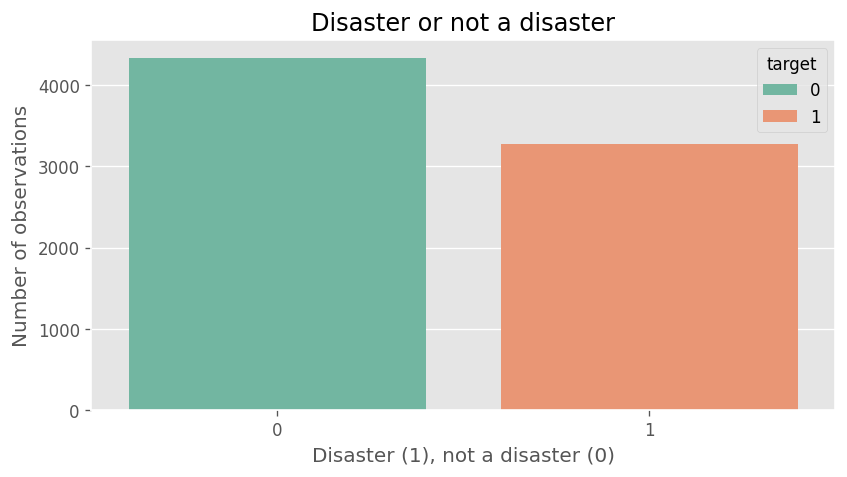

In [7]:
sns.countplot(data=tweet, x = 'target', hue = 'target', palette = "Set2")
plt.title('Disaster or not a disaster')
plt.xlabel('Disaster (1), not a disaster (0)')
plt.ylabel('Number of observations')
plt.show()

In [8]:
# Check the actual number of observations for each of the target variable
tweet['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

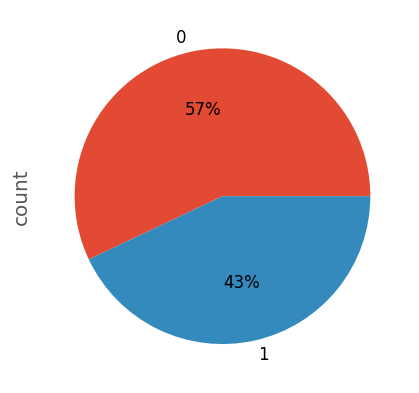

In [9]:
# Create a pie plot to check the proportion of observations in each target. Display as a percentage
tweet['target'].value_counts().plot.pie(autopct = '%1.f%%')
plt.show()

### Number of characters in a tweet. Distribution in the number of characters

In [10]:
# Install pre-process package from git.
# This is available here: https://github.com/laxmimerit/preprocess_kgptalkie
!pip install git+https://github.com/laxmimerit/preprocess_kgptalkie.git

  Cloning https://github.com/laxmimerit/preprocess_kgptalkie.git to c:\users\user\appdata\local\temp\pip-req-build-m1y8s2fs
  Resolved https://github.com/laxmimerit/preprocess_kgptalkie.git to commit 0f56a6502679f6750b7f0ffed98f590d1f0246bd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/laxmimerit/preprocess_kgptalkie.git 'C:\Users\User\AppData\Local\Temp\pip-req-build-m1y8s2fs'


In [11]:
import preprocess_kgptalkie as kgp

C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\torch\__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ..\torch\csrc\tensor\python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


Create a feature for the number of characters in the tweet

In [12]:
# Create a feature for character length
tweet['char_count'] = tweet['text'].apply(lambda x: len(x))

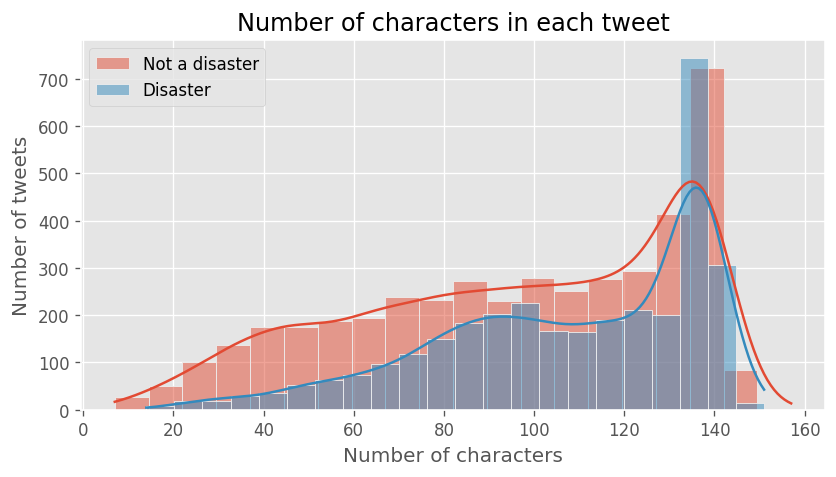

In [13]:
# plot the distribution of characters in each tweet
tweet0 = tweet[tweet['target']==0]
tweet1 = tweet[tweet['target']==1]
sns.histplot(tweet0['char_count'], kde=True, label = "Not a disaster")
sns.histplot(tweet1['char_count'], kde=True, label = "Disaster")
plt.title('Number of characters in each tweet')
plt.xlabel('Number of characters')
plt.ylabel('Number of tweets')
plt.legend()
plt.show()

In [14]:
tweet

,id,keyword,location,text,target,char_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,69
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,133
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,65
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,88
...,...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse into nearby homes http://t.co/STfMbbZFB5,1,83
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control wild fires in California even in the Northern part of the state. Very troubling.,1,125
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. http://t.co/zDtoyd8EbJ,1,65
7611,10872,NaN,NaN,Police investigating after an e-bike collided with a car in Little Portugal. E-bike rider suffered serious non-life threatening injuries.,1,137


[]

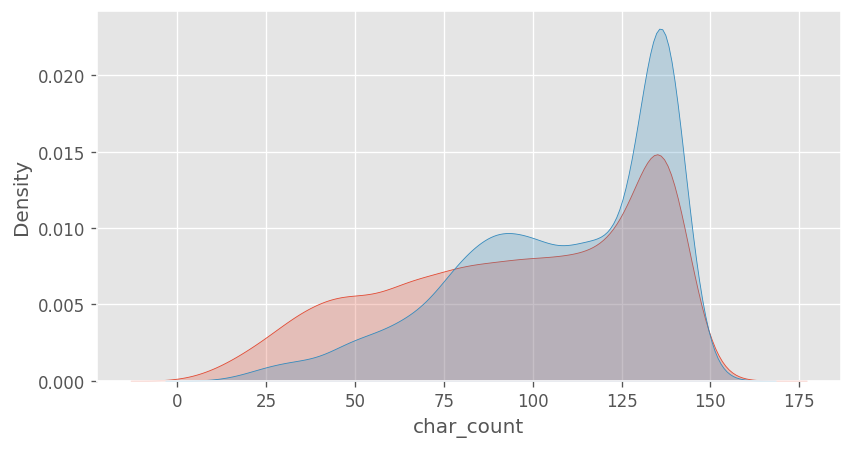

In [15]:
sns.kdeplot(tweet[tweet['target']==0]['char_count'], fill = True)
sns.kdeplot(tweet[tweet['target']==1]['char_count'], fill = True)
plt.plot()

### Number of words in a tweet

In [16]:
# Create a feature for the number of words
tweet['word_count'] = tweet['text'].apply(lambda x:  len(x.split(" ")))

[]

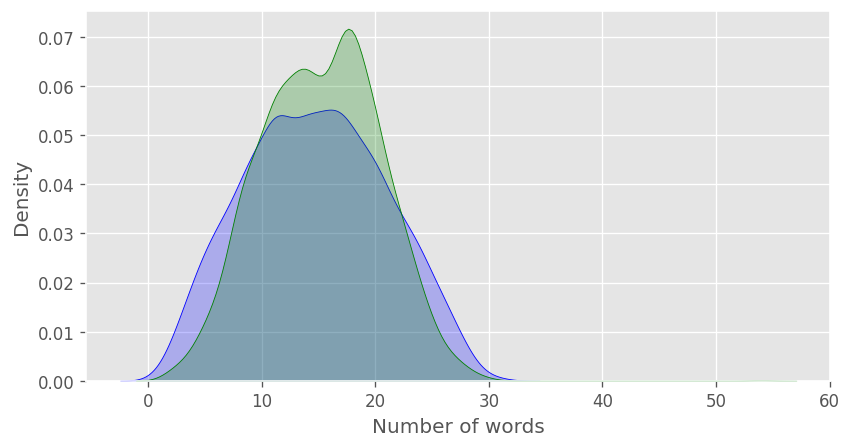

In [17]:
# KDE plot for the number of words in each tweet
sns.kdeplot(tweet[tweet['target']==0]['word_count'], fill = True, color = 'blue')
sns.kdeplot(tweet[tweet['target']==1]['word_count'], fill = True, color = 'green')
plt.xlabel('Number of words')
plt.plot()

### Average word length for each tweet

In [18]:
mylist = "I love Maho scrotums"

In [19]:
# Create a function to compute the average length of each word in each tweet
def avg_word_length(text):

    # Split the tweet into a list
    text = word_tokenize(text)

    # initiate an expty list to store the lengths of each word in the tweet list
    count = [] 
    for i in text:
        count.append(len(i))

    # Return the average word length as the sum of all word lengths divided by the number of words for each tweet
    return sum(count)/len(count)

In [20]:
# Create a feature for the number of words
tweet['avg_word_length'] = tweet['text'].apply(lambda x: avg_word_length(x))

[]

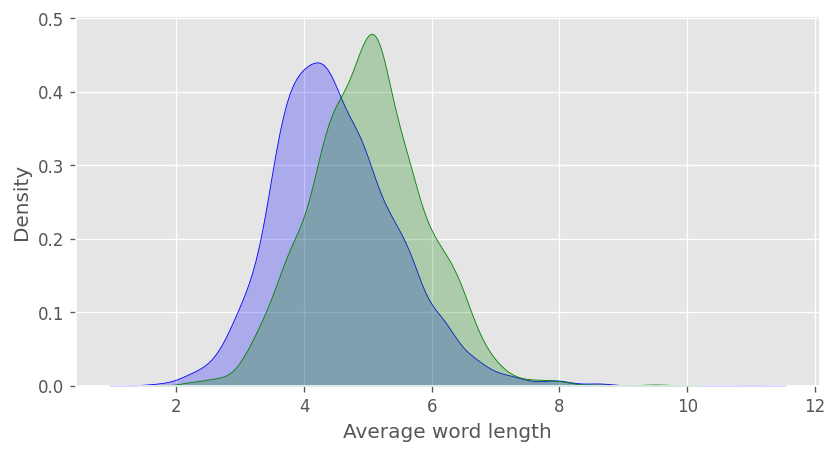

In [21]:
# KDE plot for the average word length of each tweet
sns.kdeplot(tweet[tweet['target']==0]['avg_word_length'], fill = True, color = 'blue')
sns.kdeplot(tweet[tweet['target']==1]['avg_word_length'], fill = True, color = 'green')
plt.xlabel('Average word length')
plt.plot()

### stop words count

In [22]:
# Create a function to count the number of stop words
stop_words = stopwords.words('english')
def stop_words_count(text):

    # Initialise a counter for the number of stop words
    count = 0
    
    # Tokenise to split the tweets into a list
    text = word_tokenize(text)
    
    # Loop[ through all of the words in each tweet and count the number that are stop words
    for word in text:
        if word in stop_words:
            count+=1
    return count

In [23]:
# Create a column for the number of stop words in each tweet
tweet['stop_word_count'] = tweet['text'].apply(lambda x: stop_words_count(x))

[]

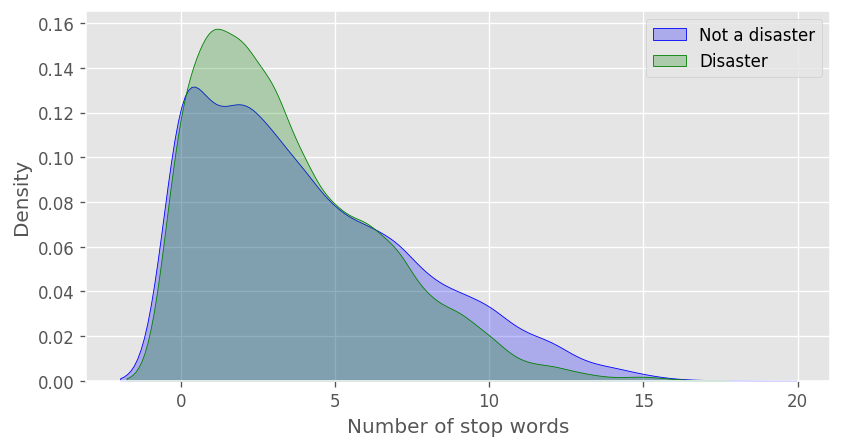

In [24]:
# KDE plot for the number of stop words in each tweet
sns.kdeplot(tweet[tweet['target']==0]['stop_word_count'], fill = True, color = 'blue', label = "Not a disaster")
sns.kdeplot(tweet[tweet['target']==1]['stop_word_count'], fill = True, color = 'green', label = "Disaster")
plt.xlabel('Number of stop words')
plt.legend()
plt.plot()

## Text Pre-Processing

In [25]:
# Create a function to convert the tweet to lower case and replce \\, _, . with a space
def lower_case(tweet):
    results = []
    for i in tweet['text']:
        i = str(i).lower().replace('\\',' ').replace('_',' ').replace('.',' ')
        results.append(i)
    tweet['text'] = results
    return tweet

In [26]:
# Create a function to remove email addresses from the tweet
def remove_email(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub(r'\S*@\S*\s?', "", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [27]:
# Create a function to remove urls from the tweet
def remove_url(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', "", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [28]:
# Create a function to remove duplicate letters from the tweet
def remove_dup_char(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub("([a-zA-Z])\\1{2,}", "\\1", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [29]:
# Create a function to remove special characters from the tweet
def remove_special(tweet):
    results = []
    for i in tweet['text']:
        # Replace anything that is not a letter, number of space with blank
        i = re.sub('[^A-Za-z0-9 ]+', '', i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [33]:
tweet = (tweet
         .pipe(lower_case)
         .pipe(remove_email)
         .pipe(remove_url)
         .pipe(remove_dup_char)
         .pipe(remove_special)
        )

In [34]:
tweet.head()

,id,keyword,location,text,target,char_count,word_count,avg_word_length,stop_word_count
0,1,NaN,NaN,our deeds are the reason of this earthquake may allah forgive us all,1,69,13,4.071429,5
1,4,NaN,NaN,forest fire near la ronge sask canada,1,38,7,4.000000,0
2,5,NaN,NaN,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected,1,133,22,4.666667,9
3,6,NaN,NaN,13000 people receive wildfires evacuation orders in california,1,65,9,6.333333,1
4,7,NaN,NaN,just got sent this photo from ruby alaska as smoke from wildfires pours into a school,1,88,17,4.000000,6


## Word Cloud

### Most frequent words for disaster tweets

In [110]:
# Compute frequency of each word in the tweets
wordfreq = tweet[tweet['target']==1]['text'].str.split(expand=True).stack().value_counts()

In [111]:
# Convert the text from the word frequencies into a string
wordfreq_df = pd.DataFrame(wordfreq)
disaster_freq = ' '.join(wordfreq_df.index)

(-0.5, 799.5, 499.5, -0.5)

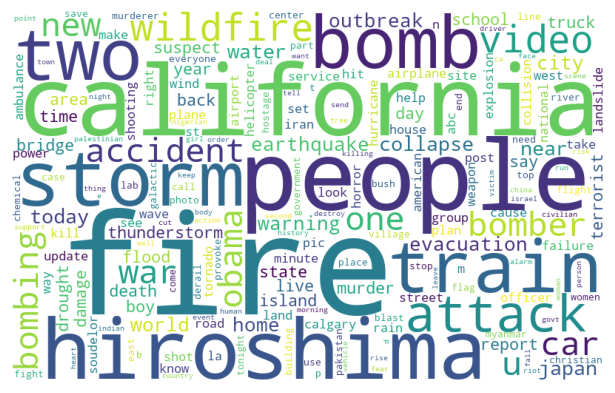

In [112]:
# Create a wordcloud
wc = WordCloud(background_color='white', colormap = 'viridis', width = 800, height = 500).generate(disaster_freq)
plt.axis("off")
plt.imshow(wc)
plt.axis("off")